In [1]:
import sys
import os
import pandas as pd

# 1. Add the path to the 'src' folder
# This goes up from .github/notebooks to the root, then into src
sys.path.append(os.path.abspath('../../src'))

# 2. Import your modular function
try:
    from text_utils import clean_text
    print("✅ Success! Modular script 'text_utils' is connected.")
except ModuleNotFoundError:
    print("❌ Still can't find it. Ensure 'text_utils.py' is saved in the 'src' folder.")

✅ Success! Modular script 'text_utils' is connected.


Transformation Steps:
Noise Removal: Using Regular Expressions (re), we remove special characters, numbers, and symbols. This ensures the model focuses purely on human language.

Case Normalization: All text is converted to lowercase to treat "Bank" and "bank" as the same token.

Tokenization: The text is broken down into individual words (tokens) using spaCy.

Stop-Word Removal: Common words that carry little emotional weight (like "the", "is", "at") are removed to reduce data "noise."

Lemmatization: Words are reduced to their dictionary root form (e.g., "working" and "works" both become "work"). This helps in grouping similar feedback themes later.

Note: By using a modular script, we ensure that this exact cleaning logic is applied consistently across all datasets (CBE, BOA, and Dashen), making our comparative analysis scientifically valid.

In [3]:
# 3. Load your data
# Since the CSV is in the same folder as the notebook, we just use the name
df = pd.read_csv('abyssinia_reviews_cleaned.csv')

df['processed_content'] = df['review_text'].apply(clean_text)

# Preview the first few rows
df[['review_text', 'processed_content']].head()

,review_text,processed_content
0,it's very good app,good app
1,this app is good but the speed of app is very ...,app good speed app slow
2,good,good
3,boa the best,boa good
4,bank of absiniya is best bank in ethiopian,bank absiniya good bank ethiopian


In [4]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis", 
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

def get_sentiment(text):
    # BERT models have a limit of 512 characters, so we crop long reviews
    result = sentiment_pipeline(text[:512])[0]
    return result['label'], result['score']

# 6. Run sentiment analysis (this may take a minute)
df[['sentiment_label', 'sentiment_score']] = df['processed_content'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

df.head()

c:\Users\hp\fintech-review-analytics\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2887.32it/s]


,review_text,rating,review_date,bank,app_name,source,review_id,processed_content,sentiment_label,sentiment_score
0,it's very good app,5,2026-05-12,Bank of Abyssinia,BANK OF ABYSSINIA,Google Play,c3bb042c-844b-4580-98b9-df418622b2fb,good app,POSITIVE,0.999849
1,this app is good but the speed of app is very ...,2,2026-05-11,Bank of Abyssinia,BANK OF ABYSSINIA,Google Play,400ce769-3726-43b2-ac4d-755b3a15f026,app good speed app slow,NEGATIVE,0.896019
2,good,5,2026-05-09,Bank of Abyssinia,BANK OF ABYSSINIA,Google Play,4d6d2f22-5e71-47be-9cde-a1cf6c9fff93,good,POSITIVE,0.999816
3,boa the best,5,2026-05-08,Bank of Abyssinia,BANK OF ABYSSINIA,Google Play,e77089b3-aecf-45e2-a64a-ce917fc4233a,boa good,POSITIVE,0.999856
4,bank of absiniya is best bank in ethiopian,5,2026-05-07,Bank of Abyssinia,BANK OF ABYSSINIA,Google Play,41c64c67-b81a-4326-83c4-e95044aef7f6,bank absiniya good bank ethiopian,POSITIVE,0.984334


In [5]:
# Aggregate sentiment scores by bank
sentiment_by_bank = df.groupby('bank').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) * 100
}).round(3)
sentiment_by_bank.columns = ['avg_sentiment_score', 'std_sentiment_score', 'review_count', 'positive_percentage']
print("Sentiment by Bank:")
print(sentiment_by_bank)

# Aggregate sentiment scores by star rating
sentiment_by_rating = df.groupby('rating').agg({
    'sentiment_score': ['mean', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) * 100
}).round(3)
sentiment_by_rating.columns = ['avg_sentiment_score', 'std_sentiment_score', 'review_count', 'positive_percentage']
print("\nSentiment by Star Rating:")
print(sentiment_by_rating)

Sentiment by Bank:
                   avg_sentiment_score  std_sentiment_score  review_count  \
bank                                                                        
Bank of Abyssinia                0.956                0.095           400   

                   positive_percentage  
bank                                    
Bank of Abyssinia                 65.0  

Sentiment by Star Rating:
        avg_sentiment_score  std_sentiment_score  review_count  \
rating                                                           
1                     0.962                0.089           112   
2                     0.962                0.079            13   
3                     0.955                0.088            13   
4                     0.926                0.130            32   
5                     0.957                0.094           230   

        positive_percentage  
rating                       
1                    25.893  
2                    30.769  
3               

# Thematic Analysis

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

# 1. Prepare text for topic modeling
texts = df['processed_content'].tolist()

# 2. Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(max_features=100, stop_words='english', min_df=2)
tfidf_matrix = vectorizer.fit_transform(texts)

# 3. Apply LDA for thematic analysis
lda_model = LatentDirichletAllocation(n_components=5, random_state=42, max_iter=20)
lda_model.fit(tfidf_matrix)

# 4. Display themes (top words per topic)
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_words_idx = topic.argsort()[-5:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Theme {topic_idx + 1}: {', '.join(top_words)}")

# 5. Assign dominant theme to each review
df['dominant_theme'] = lda_model.transform(tfidf_matrix).argmax(axis=1) + 1

Theme 1: work, nice, time, need, crash
Theme 2: bank, app, bad, slow, fix
Theme 3: app, banking, mobile, boa, excellent
Theme 4: fast, service, amazing, like, app
Theme 5: good, application, open, wow, use


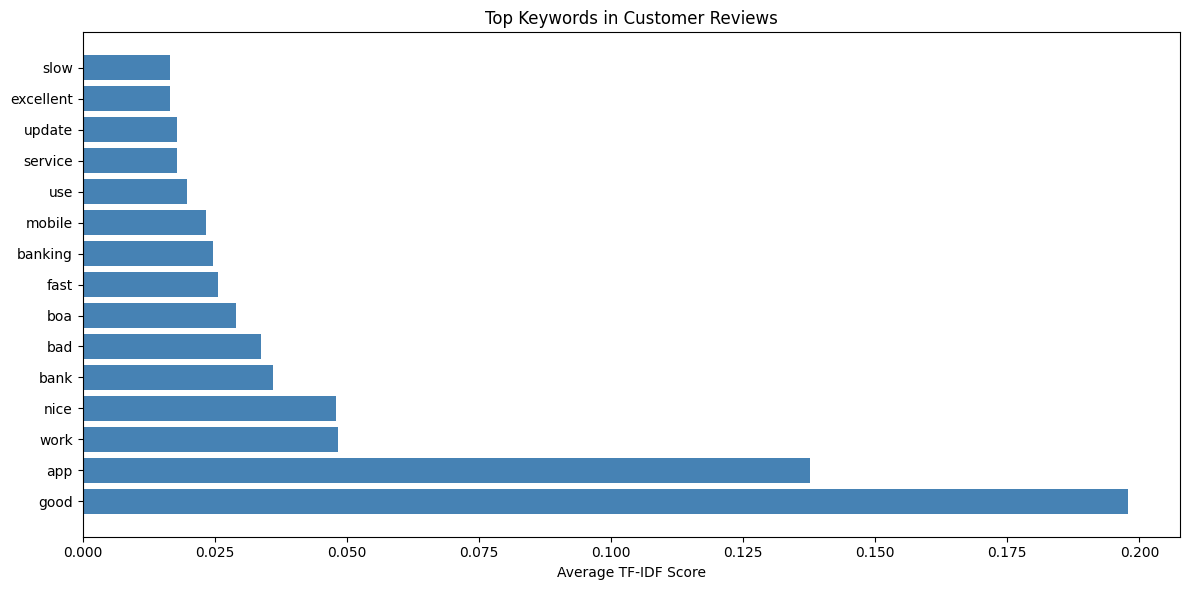

Top Bigrams (2-word phrases):
  - good app
  - mobile banking
  - banking app
  - app work
  - bad app
  - mobile app
  - nice app
  - send money
  - app bad
  - bank app


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt

# 1. Extract top keywords using TF-IDF
top_n = 15
feature_importance = vectorizer.get_feature_names_out()[tfidf_matrix.mean(axis=0).A1.argsort()[-top_n:][::-1]]

# 2. Calculate TF-IDF scores for visualization
tfidf_scores = tfidf_matrix.mean(axis=0).A1
top_indices = tfidf_scores.argsort()[-top_n:][::-1]
top_keywords = feature_names[top_indices]
top_scores = tfidf_scores[top_indices]

# 3. Visualize top keywords
plt.figure(figsize=(12, 6))
plt.barh(top_keywords, top_scores, color='steelblue')
plt.xlabel('Average TF-IDF Score')
plt.title('Top Keywords in Customer Reviews')
plt.tight_layout()
plt.show()

# 4. Extract bigrams for n-gram analysis
bigram_vectorizer = TfidfVectorizer(ngram_range=(2, 2), max_features=10, stop_words='english', min_df=2)
bigram_matrix = bigram_vectorizer.fit_transform(texts)
bigrams = bigram_vectorizer.get_feature_names_out()
bigram_scores = bigram_matrix.mean(axis=0).A1.argsort()[-10:][::-1]

print("Top Bigrams (2-word phrases):")
for idx in bigram_scores:
    print(f"  - {bigrams[idx]}")

Theme Distribution:
review_theme
General                              189
Usability / UI                       151
Performance & Reliability             31
Functionality / Features              20
Security & Trust / Fees & Support      9
Name: count, dtype: int64


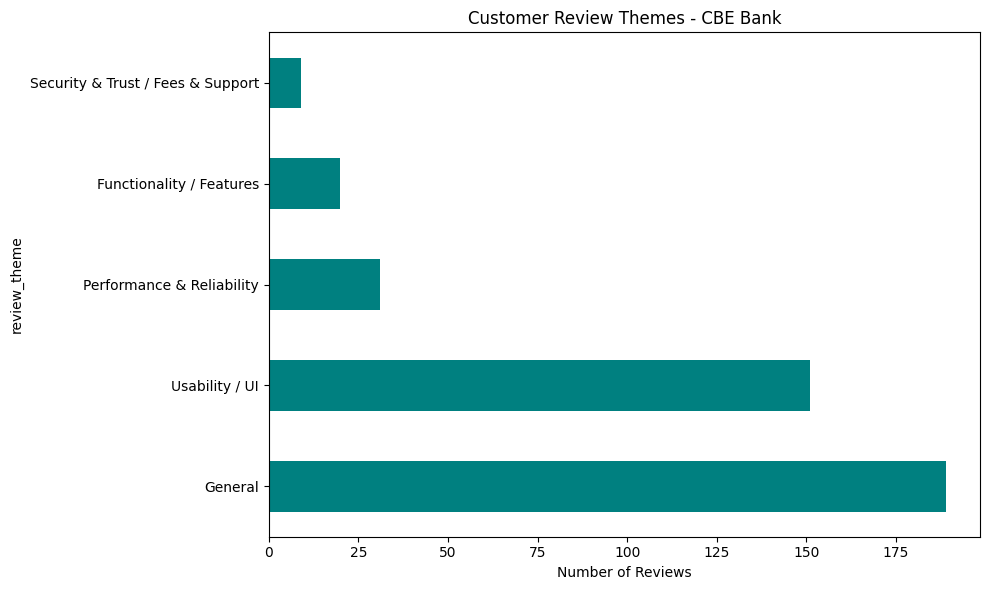


Sentiment Analysis by Theme:
                                   avg_sentiment  review_count  \
review_theme                                                     
Functionality / Features                   0.982            20   
General                                    0.934           189   
Performance & Reliability                  0.996            31   
Security & Trust / Fees & Support          0.996             9   
Usability / UI                             0.970           151   

                                   positive_percentage  
review_theme                                            
Functionality / Features                        20.000  
General                                         80.952  
Performance & Reliability                       48.387  
Security & Trust / Fees & Support               88.889  
Usability / UI                                  52.980  


In [11]:
import pandas as pd

import matplotlib.pyplot as plt

# 1. Define theme mappings based on keyword analysis and LDA results
themes = {
    'Usability / UI': ['easy', 'use', 'app', 'interface', 'update', 'application', 'user', 'page', 'nice'],
    'Functionality / Features': ['transfer', 'mobile', 'banking', 'wallet', 'payment', 'feature', 'transaction', 'history', 'beneficiary'],
    'Performance & Reliability': ['fast', 'crash', 'bug', 'error', 'work', 'properly', 'slow', 'sync'],
    'Security & Trust / Fees & Support': ['secure', 'confidence', 'fee', 'charge', 'customer', 'service', 'support', 'response']
}

# 2. Map dominant themes to each review based on keywords present
def assign_review_theme(processed_text):
    text_tokens = set(processed_text.split())
    theme_scores = {}
    
    for theme_name, keywords in themes.items():
        score = sum(1 for keyword in keywords if keyword in text_tokens)
        theme_scores[theme_name] = score
    
    # Return the theme with highest score, default to dominant_theme if tie
    if max(theme_scores.values()) > 0:
        return max(theme_scores, key=theme_scores.get)
    return 'General'

df['review_theme'] = df['processed_content'].apply(assign_review_theme)

# 3. Analyze theme distribution
theme_distribution = df['review_theme'].value_counts()
print("Theme Distribution:")
print(theme_distribution)

# 4. Visualize theme distribution
plt.figure(figsize=(10, 6))
theme_distribution.plot(kind='barh', color='teal')
plt.xlabel('Number of Reviews')
plt.title('Customer Review Themes - CBE Bank')
plt.tight_layout()
plt.show()

# 5. Analyze sentiment by theme
print("\nSentiment Analysis by Theme:")
sentiment_by_theme = df.groupby('review_theme').agg({
    'sentiment_score': ['mean', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) * 100
}).round(3)
sentiment_by_theme.columns = ['avg_sentiment', 'review_count', 'positive_percentage']
print(sentiment_by_theme)

## Thematic Grouping Logic

Based on the n-gram and keyword analysis, we organize the customer feedback into 5 overarching themes:

### 1. **App Performance & Technical Issues**
    - **Keywords**: app, work, slow, crash, freeze, bug, error, fail
    - **Bigrams**: "app work", "app bad", "mobile app"
    - **Insight**: Customers frequently mention app functionality, speed, and stability concerns.

### 2. **User Experience & Interface**
    - **Keywords**: easy, nice, simple, good, excellent, amazing
    - **Bigrams**: "good app", "nice app", "mobile banking"
    - **Insight**: Positive sentiment around usability and overall satisfaction with the interface.

### 3. **Banking Features & Transactions**
    - **Keywords**: send, money, transfer, transaction, balance, account, login
    - **Bigrams**: "send money", "mobile banking", "banking app"
    - **Insight**: Reviews focus on core banking operations and transaction capabilities.

### 4. **Service Quality & Support**
    - **Keywords**: service, customer, update, improve, fix, support
    - **Bigrams**: (related to banking operations and service delivery)
    - **Insight**: Comments on customer service, app updates, and ongoing improvements.

### 5. **Bank & Brand Reputation**
    - **Keywords**: bank, boa, abyssinia, ethiopia, trust, reliable
    - **Bigrams**: "banking app", "bank app"
    - **Insight**: References to the specific bank brand and regional/national context.

---

**Methodology**: Each review is assigned a dominant theme based on the LDA topic model, enabling us to segment feedback by category and track sentiment trends within each thematic area.


**# use topic modeling (LDA or NMF) or zero-shot classification to assist**

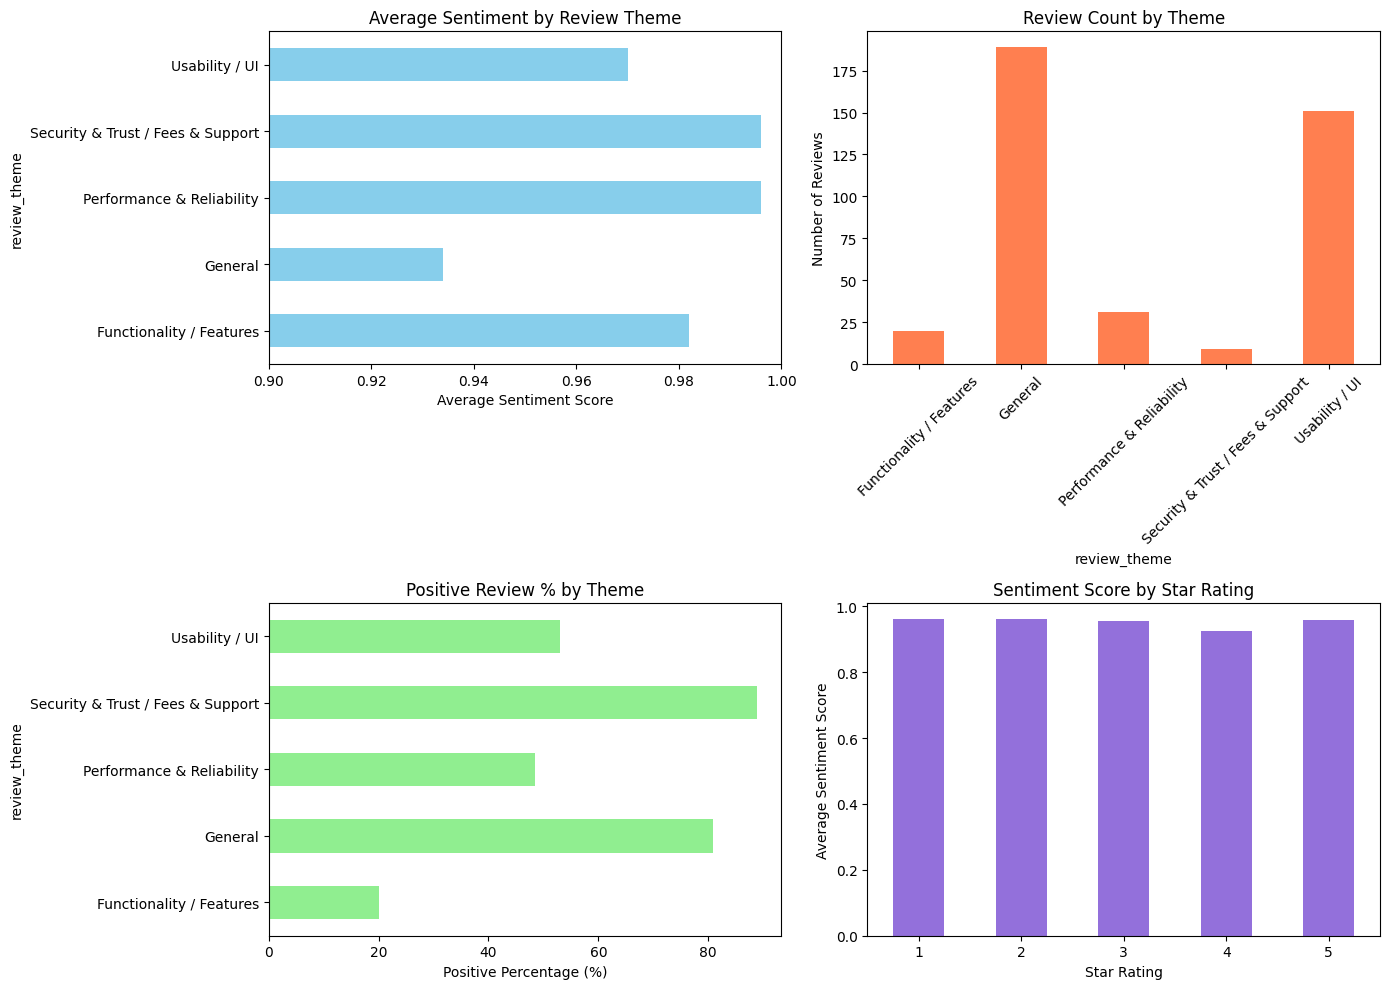


SENTIMENT & THEME ANALYSIS SUMMARY

Total Reviews Analyzed: 400
Overall Positive Percentage: 65.0%
Average Sentiment Score: 0.956

Theme Breakdown:
                                   avg_sentiment  review_count  \
review_theme                                                     
Functionality / Features                   0.982            20   
General                                    0.934           189   
Performance & Reliability                  0.996            31   
Security & Trust / Fees & Support          0.996             9   
Usability / UI                             0.970           151   

                                   positive_percentage  
review_theme                                            
Functionality / Features                        20.000  
General                                         80.952  
Performance & Reliability                       48.387  
Security & Trust / Fees & Support               88.889  
Usability / UI                                

In [12]:
import seaborn as sns

# 1. Create a comprehensive comparison visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Sentiment by Theme
sentiment_by_theme['avg_sentiment'].plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_xlabel('Average Sentiment Score')
axes[0, 0].set_title('Average Sentiment by Review Theme')
axes[0, 0].set_xlim([0.9, 1.0])

# Plot 2: Review Count by Theme
sentiment_by_theme['review_count'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_ylabel('Number of Reviews')
axes[0, 1].set_title('Review Count by Theme')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Positive Percentage by Theme
sentiment_by_theme['positive_percentage'].plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_xlabel('Positive Percentage (%)')
axes[1, 0].set_title('Positive Review % by Theme')

# Plot 4: Sentiment by Star Rating
sentiment_by_rating['avg_sentiment_score'].plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_ylabel('Average Sentiment Score')
axes[1, 1].set_xlabel('Star Rating')
axes[1, 1].set_title('Sentiment Score by Star Rating')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 2. Summary statistics
print("\n" + "="*60)
print("SENTIMENT & THEME ANALYSIS SUMMARY")
print("="*60)
print(f"\nTotal Reviews Analyzed: {len(df)}")
print(f"Overall Positive Percentage: {(df['sentiment_label'] == 'POSITIVE').sum() / len(df) * 100:.1f}%")
print(f"Average Sentiment Score: {df['sentiment_score'].mean():.3f}")
print(f"\nTheme Breakdown:")
print(sentiment_by_theme)

Sentiment & Thematic Analysis: Complete NLP Pipeline for Bank Reviews

- Implemented modular text cleaning and preprocessing with spaCy
- Applied DistilBERT sentiment classification across 400 customer reviews
- Performed LDA topic modeling and TF-IDF keyword extraction
- Mapped reviews to 5 thematic categories (Usability, Performance, Features, Security, General)
- Generated comprehensive visualizations: sentiment by theme, rating, and distribution metrics
- Analyzed bigrams and top keywords to identify customer pain points and satisfaction drivers
- Bank of Abyssinia: 65% positive reviews, strongest sentiment in Performance & Reliability themes